# A.2. TRANSFER LEARNING & FINE – TUNING MODEL (Pytorch BASED)

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
import matplotlib.pyplot as plt
import timm
from dataset import get_dataloaders


/home/vpcuser/miniconda3/envs/atm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
train_loader, val_loader, class_names = get_dataloaders(
    root_dir="dataset",
    val_size=500,
    batch_size=32,
    image_size=150,
    num_workers=2
)
print("Classes:", class_names)
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Classes: ['cats', 'dogs', 'panda']
Train batches: 79
Val batches: 16


In [4]:
criterion = nn.CrossEntropyLoss()


In [5]:
model = timm.create_model("xception", pretrained=True, num_classes=len(class_names))
model = model.to(device)

/home/vpcuser/miniconda3/envs/atm/lib/python3.12/site-packages/timm/models/_factory.py:175: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


In [7]:
for name, param in model.named_parameters():
    if not name.startswith("fc"):
        param.requires_grad = False
optimizer = AdamW(model.fc.parameters(), lr=1e-3)

**Thực hiện fine-tuning (1 epoch) trên toàn bộ mô hình**

In [8]:
epochs_stage1 = 2
stage1_train_loss, stage1_val_loss = [], []
stage1_train_acc, stage1_val_acc = [], []

for epoch in range(epochs_stage1):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    tr_l = train_loss / train_total
    tr_a = (train_correct / train_total) * 100.0
    vl_l = val_loss / val_total
    vl_a = (val_correct / val_total) * 100.0

    stage1_train_loss.append(tr_l)
    stage1_train_acc.append(tr_a)
    stage1_val_loss.append(vl_l)
    stage1_val_acc.append(vl_a)

    print(f"Stage 1 | Epoch {epoch+1}/{epochs_stage1} | Train Loss: {tr_l:.4f} Acc: {tr_a:.2f}% | Val Loss: {vl_l:.4f} Acc: {vl_a:.2f}%")


Stage 1 | Epoch 1/2 | Train Loss: 0.5223 Acc: 82.48% | Val Loss: 0.3055 Acc: 92.00%
Stage 1 | Epoch 2/2 | Train Loss: 0.3304 Acc: 89.08% | Val Loss: 0.2442 Acc: 92.20%


In [10]:
for param in model.parameters():
    param.requires_grad = True


In [11]:
backbone_params = [p for n, p in model.named_parameters() if not n.startswith("fc")]
fc_params = model.fc.parameters()

optimizer = AdamW([
    {"params": backbone_params, "lr": 1e-5},
    {"params": fc_params, "lr": 1e-4}
])

In [12]:
epochs_stage2 = 10
patience = 3
best_val_loss = float("inf")
stop_count = 0
best_weights = None

stage2_train_loss, stage2_val_loss = [], []
stage2_train_acc, stage2_val_acc = [], []

for epoch in range(epochs_stage2):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    tr_l = train_loss / train_total
    tr_a = (train_correct / train_total) * 100.0
    vl_l = val_loss / val_total
    vl_a = (val_correct / val_total) * 100.0

    stage2_train_loss.append(tr_l)
    stage2_train_acc.append(tr_a)
    stage2_val_loss.append(vl_l)
    stage2_val_acc.append(vl_a)

    print(f"Stage 2 | Epoch {epoch+1:02d}/{epochs_stage2} | Train Loss: {tr_l:.4f} Acc: {tr_a:.2f}% | Val Loss: {vl_l:.4f} Acc: {vl_a:.2f}%")

    if vl_l < best_val_loss:
        best_val_loss = vl_l
        best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        stop_count = 0
    else:
        stop_count += 1
        if stop_count >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            model.load_state_dict(best_weights)
            break

Stage 2 | Epoch 01/10 | Train Loss: 0.2732 Acc: 90.72% | Val Loss: 0.1933 Acc: 93.80%
Stage 2 | Epoch 02/10 | Train Loss: 0.2199 Acc: 92.36% | Val Loss: 0.1563 Acc: 94.40%
Stage 2 | Epoch 03/10 | Train Loss: 0.1887 Acc: 93.44% | Val Loss: 0.1718 Acc: 95.00%
Stage 2 | Epoch 04/10 | Train Loss: 0.1680 Acc: 94.00% | Val Loss: 0.1215 Acc: 95.40%
Stage 2 | Epoch 05/10 | Train Loss: 0.1511 Acc: 94.20% | Val Loss: 0.1080 Acc: 95.60%
Stage 2 | Epoch 06/10 | Train Loss: 0.1323 Acc: 95.24% | Val Loss: 0.1023 Acc: 96.00%
Stage 2 | Epoch 07/10 | Train Loss: 0.1339 Acc: 95.08% | Val Loss: 0.0994 Acc: 95.80%
Stage 2 | Epoch 08/10 | Train Loss: 0.1160 Acc: 95.64% | Val Loss: 0.1016 Acc: 95.80%
Stage 2 | Epoch 09/10 | Train Loss: 0.1134 Acc: 95.84% | Val Loss: 0.0845 Acc: 96.60%
Stage 2 | Epoch 10/10 | Train Loss: 0.1100 Acc: 95.96% | Val Loss: 0.0906 Acc: 96.40%


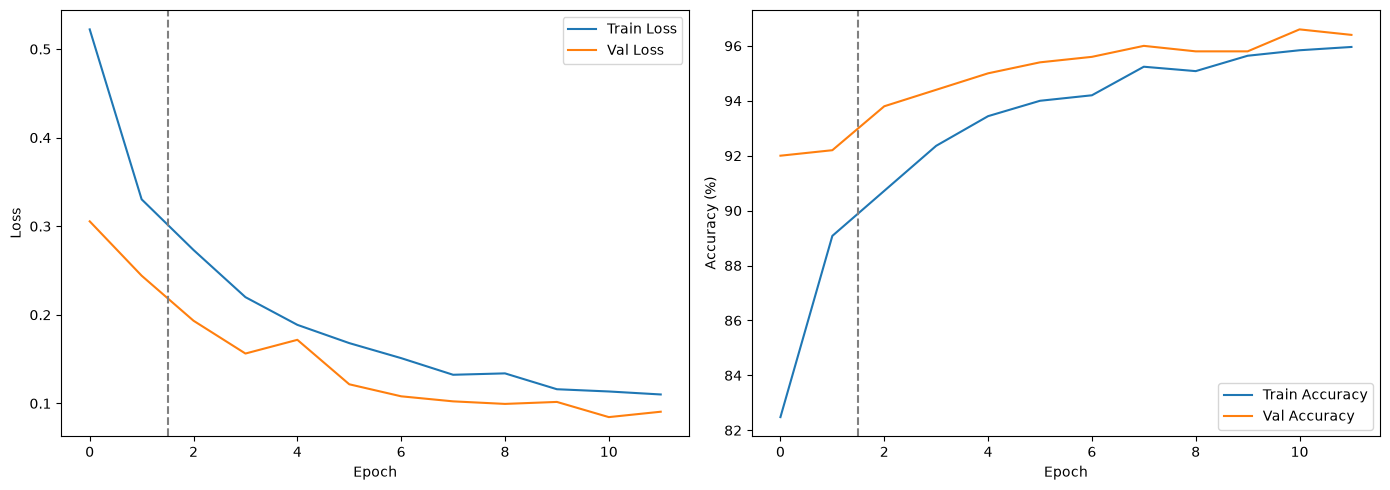

In [13]:
all_train_loss = stage1_train_loss + stage2_train_loss
all_val_loss = stage1_val_loss + stage2_val_loss
all_train_acc = stage1_train_acc + stage2_train_acc
all_val_acc = stage1_val_acc + stage2_val_acc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(all_train_loss, label="Train Loss")
axes[0].plot(all_val_loss, label="Val Loss")
axes[0].axvline(x=epochs_stage1 - 0.5, color="gray", linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(all_train_acc, label="Train Accuracy")
axes[1].plot(all_val_acc, label="Val Accuracy")
axes[1].axvline(x=epochs_stage1 - 0.5, color="gray", linestyle="--")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

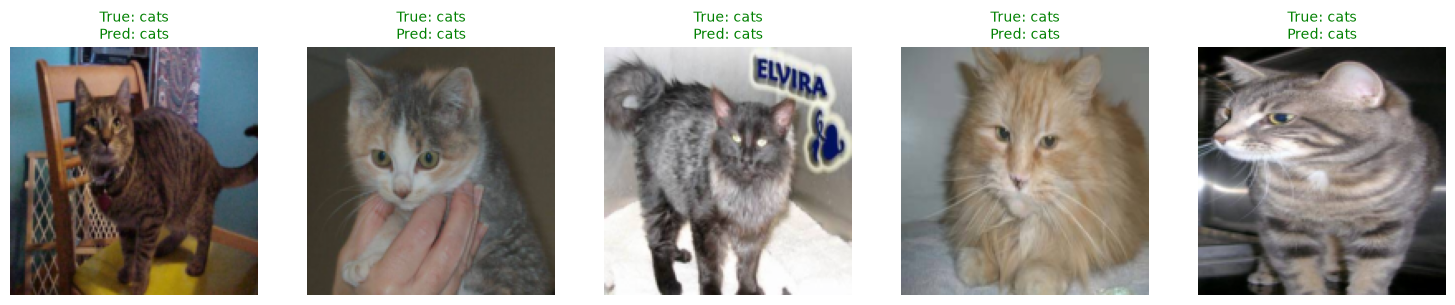

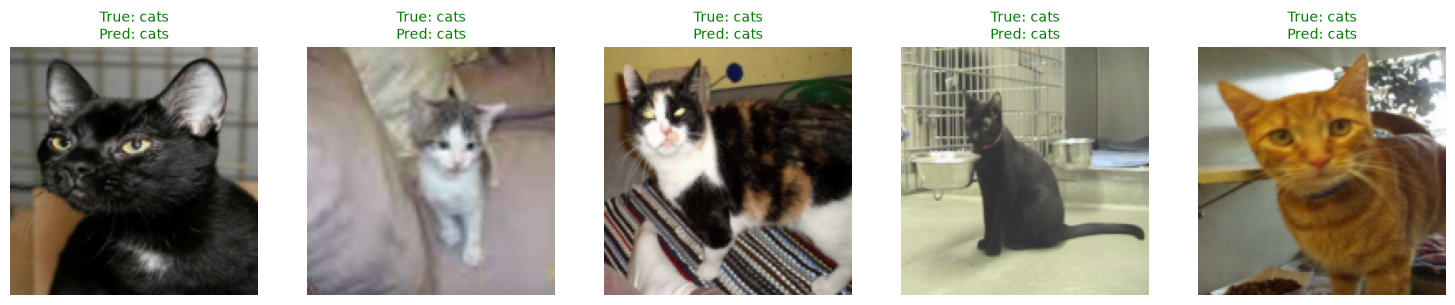

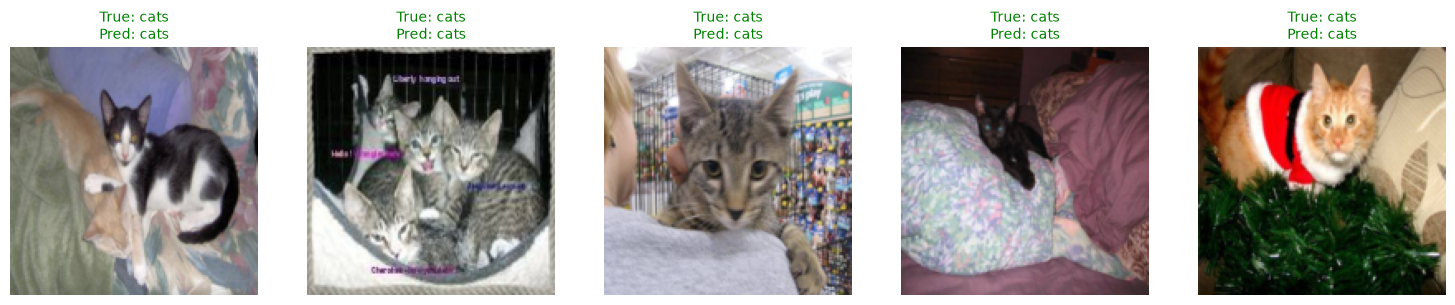

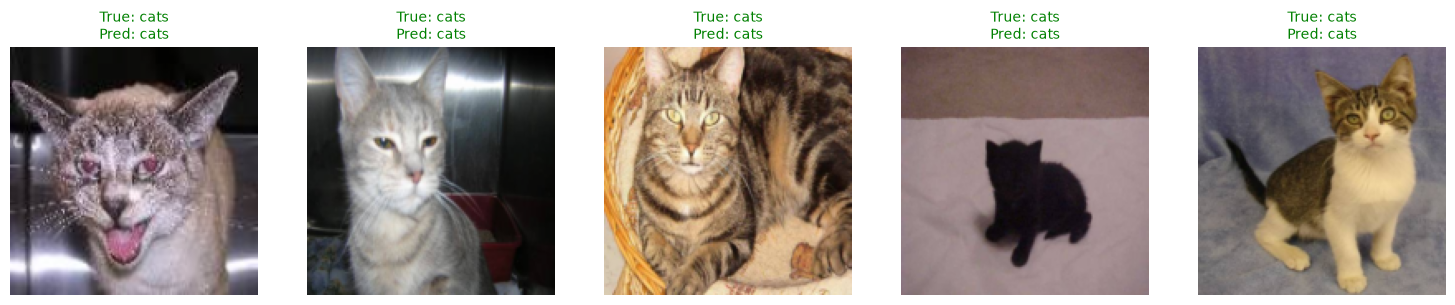

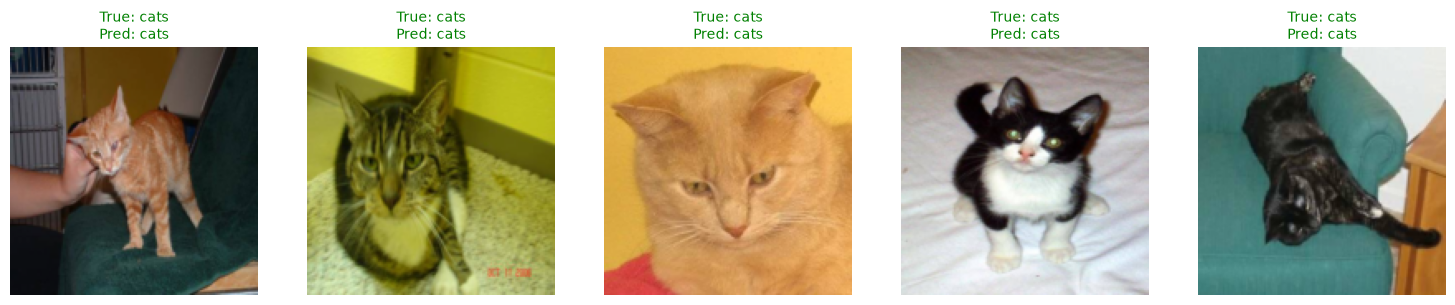

In [15]:
model.eval()
total_images = 25
images_per_row = 5
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

all_imgs, all_trues, all_preds = [], [], []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        preds = torch.argmax(outputs, dim=1).cpu()
        for i in range(images.size(0)):
            if len(all_imgs) >= total_images:
                break
            img = images[i].permute(1, 2, 0).numpy()
            img = np.clip(std * img + mean, 0, 1)
            all_imgs.append(img)
            all_trues.append(class_names[labels[i].item()])
            all_preds.append(class_names[preds[i].item()])
        if len(all_imgs) >= total_images:
            break

num_rows = int(np.ceil(len(all_imgs) / images_per_row))

for r in range(num_rows):
    fig, axes = plt.subplots(1, images_per_row, figsize=(15, 3))
    for c in range(images_per_row):
        idx = r * images_per_row + c
        if idx < len(all_imgs):
            color = "green" if all_trues[idx] == all_preds[idx] else "red"
            axes[c].imshow(all_imgs[idx])
            axes[c].set_title(f"True: {all_trues[idx]}\nPred: {all_preds[idx]}", color=color, fontsize=10)
        axes[c].axis("off")
    plt.tight_layout()
    plt.show()


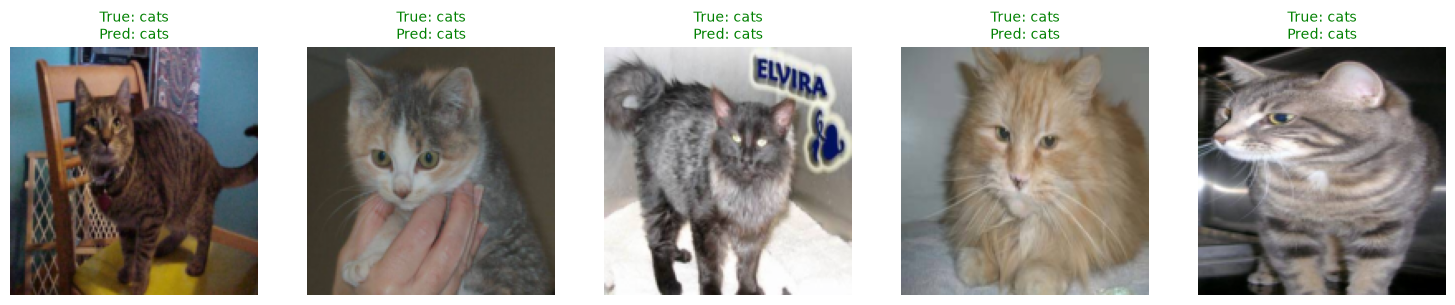

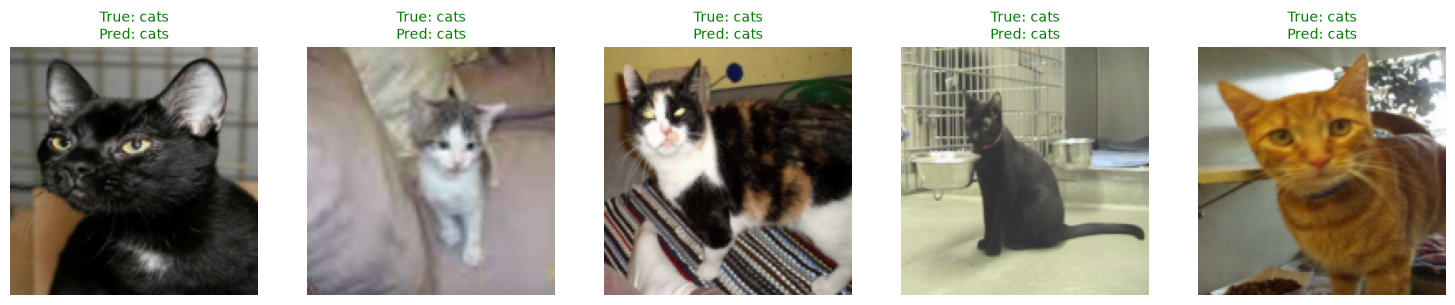

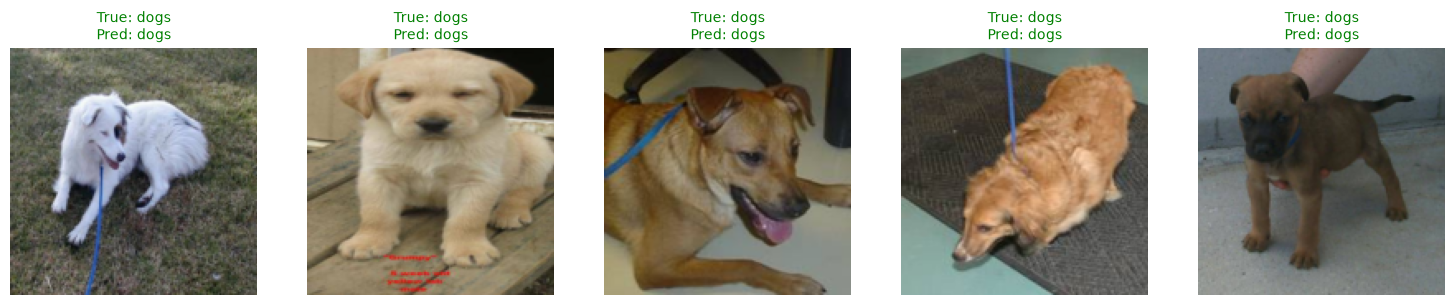

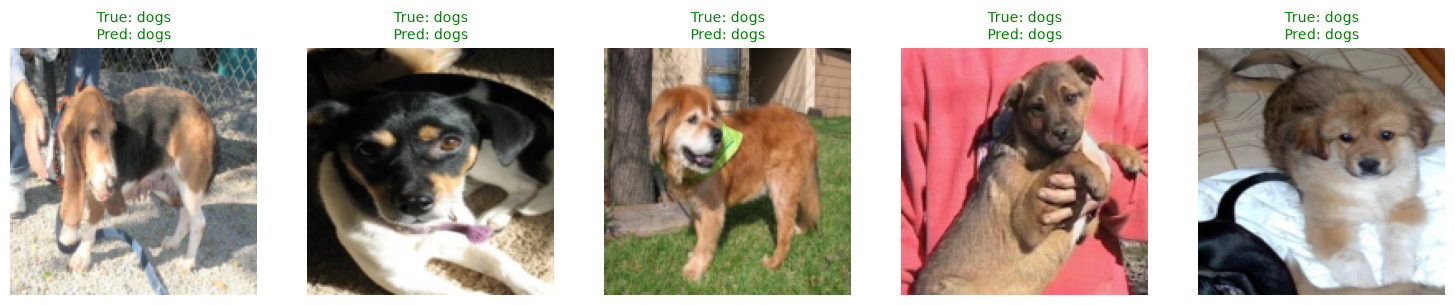

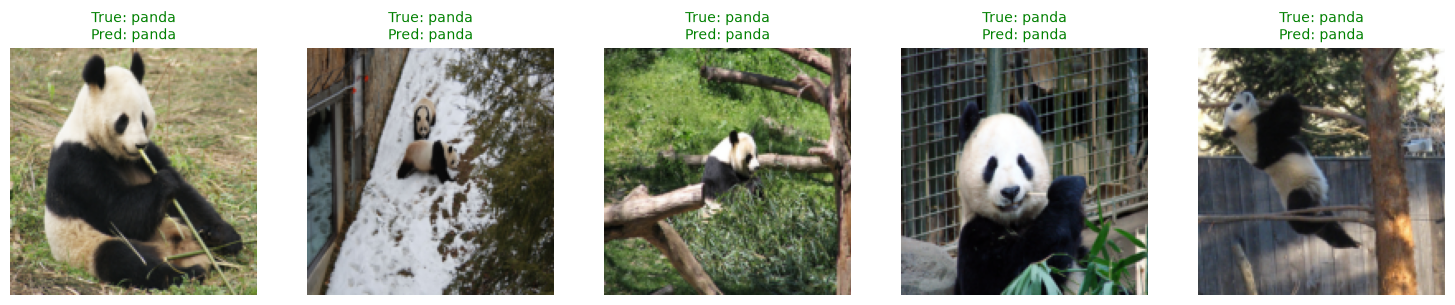

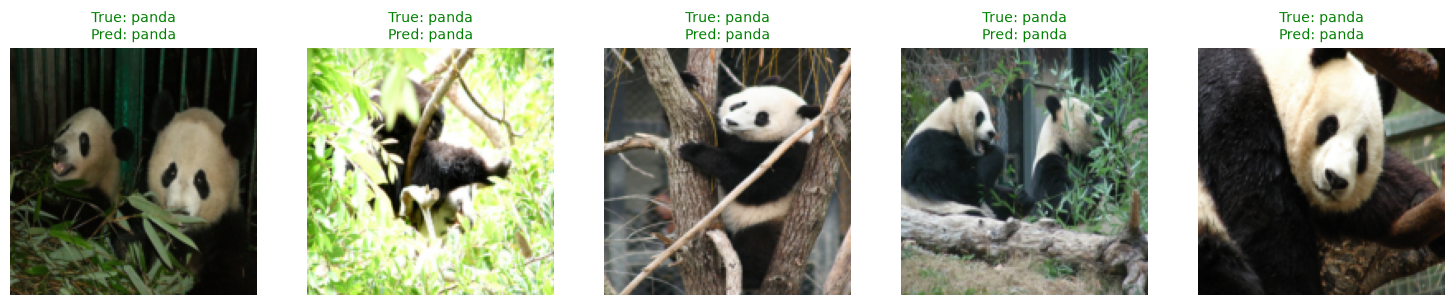

In [16]:
model.eval()
images_per_class = 10
images_per_row = 5
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

class_samples = {cls_name: [] for cls_name in class_names}

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        preds = torch.argmax(outputs, dim=1).cpu()

        for i in range(images.size(0)):
            true_cls = class_names[labels[i].item()]
            pred_cls = class_names[preds[i].item()]

            if len(class_samples[true_cls]) < images_per_class:
                img = images[i].permute(1, 2, 0).numpy()
                img = np.clip(std * img + mean, 0, 1)
                class_samples[true_cls].append((img, true_cls, pred_cls))

        if all(len(v) >= images_per_class for v in class_samples.values()):
            break

for cls_name in class_names:
    samples = class_samples[cls_name]
    num_rows = int(np.ceil(len(samples) / images_per_row))

    for r in range(num_rows):
        fig, axes = plt.subplots(1, images_per_row, figsize=(15, 3))
        for c in range(images_per_row):
            idx = r * images_per_row + c
            if idx < len(samples):
                img, true_lbl, pred_lbl = samples[idx]
                color = "green" if true_lbl == pred_lbl else "red"
                axes[c].imshow(img)
                axes[c].set_title(f"True: {true_lbl}\nPred: {pred_lbl}", color=color, fontsize=10)
            axes[c].axis("off")
        plt.tight_layout()
        plt.show()


### Nhận xét

Ở giai đoạn đầu khi đóng băng toàn bộ backbone Xception và chỉ huấn luyện lớp phân loại mới trong 2 epoch, mô hình nắm bắt dữ liệu rất nhanh nhờ các đặc trưng sẵn có từ ImageNet. Độ chính xác validation ngay lập tức đạt mức 92.00% ở epoch đầu và tăng lên 92.20% ở epoch thứ hai, với loss giảm nhanh từ 0.3055 xuống 0.2442. Điều này chứng minh phần trích xuất đặc trưng của Xception đã phân tách các nhóm đối tượng khá rõ ngay từ đầu.

Bước sang giai đoạn hai khi mở khóa toàn bộ mô hình để fine-tuning với tốc độ học nhỏ (1e-5 cho backbone và 1e-4 cho lớp fc), hiệu quả phân loại tăng tiến rõ rệt qua từng vòng lặp. Loss validation tiếp tục giảm sâu từ 0.1933 xuống mức tối ưu 0.0845 ở epoch thứ 9, đồng thời độ chính xác validation được nâng từ 93.80% lên mức đỉnh 96.60%. Tốc độ học nhỏ đã giúp các tầng tích chập thích ứng mượt mà với tập dữ liệu mới mà không làm xáo trộn các biểu diễn tri thức gốc.

Quá trình hội tụ diễn ra rất ổn định và lành mạnh. Đường cong loss giữa tập train và tập validation bám sát nhau qua cả 10 epoch, không xảy ra hiện tượng học vẹt hay phân kỳ. Đến cuối giai đoạn fine-tuning, độ chính xác trên tập train đạt 95.96% và trên tập validation đạt 96.40%, cho thấy mô hình giữ được khả năng tổng quát hóa đồng đều trên dữ liệu thực tế.

Đối với phần kiểm tra trực quan theo từng hàng 5 ảnh, lớp gấu trúc đạt độ chuẩn xác gần như tuyệt đối do đặc điểm hình thái và màu lông trắng đen rất đặc trưng. Sự nhầm lẫn hiếm hoi chỉ xuất hiện ở ranh giới giữa chó và mèo tại một số góc chụp cận cảnh hoặc tư thế nằm khuất dáng, nhưng tỷ lệ dự đoán đúng trên toàn bộ mẫu kiểm tra vẫn chiếm ưu thế áp đảo.

